# Hướng 1 — thay đổi weight cho chuyến hiếm

> **Mentor, việc cần làm:** *"Giữ model hiện tại làm model mốc, sau đó đặt weight lớn hơn cho các
> chuyến hiếm, cụ thể là chuyến trên 300k hoặc trên 15 km. Kiểm tra xem sai số ở hai nhóm này giảm
> bao nhiêu và kết quả chung phải đánh đổi bao nhiêu."*

> **Mentor, ràng buộc khi đánh giá:** *"Khi đánh giá, các em cần giữ nguyên nhóm chuyến giữa các
> model. Không nên để mỗi model tự chia nhóm theo giá mà chính nó dự đoán, vì như vậy các model có
> thể đang được đánh giá trên những nhóm chuyến khác nhau."*

## Thiết kế thí nghiệm

Một biến duy nhất thay đổi: **trọng số `w` gán cho chuyến hiếm trong tập train**. Mọi thứ khác giữ
nguyên — cùng thuật toán (HistGradientBoosting), cùng siêu tham số, cùng feature, cùng cách chia
train/test theo tháng. Trọng số chỉ áp lên tập train, tập test không đụng tới.

| Thành phần | Giá trị |
|---|---|
| Mốc | model Hybrid hiện tại — mọi chuyến trọng số 1 |
| Lưới trọng số | `w ∈ {1, 2, 3, 5, 10, 20}` |
| Cách định nghĩa "chuyến hiếm" | ① quãng đường `>15 km` · ② giá `>300k` · ③ **cả hai** (đúng chữ *"hoặc"* của mentor) |
| Nhánh bị tác động | chỉ **giá cơ bản**; nhánh hệ số nhân giữ nguyên của model mốc |
| Đo trên | 216.090 chuyến test độc lập, độ trễ 5 phút |

`w = 1` chính là model mốc, được **train lại** trong notebook này để làm điểm neo — nếu nó không
khớp với model mốc đã lưu thì quy trình có vấn đề và mọi so sánh phía sau đều vô nghĩa.

## Nhóm đánh giá cố định — áp đúng ràng buộc của mentor

Nhóm chia theo **giá thật** và **quãng đường**, hai đại lượng không phụ thuộc model nào. Mọi mức
trọng số đều được chấm trên **đúng những chuyến đó**, nên bảng so sánh mới có nghĩa.

Vì sao ràng buộc này quan trọng đến vậy: xem `06_NHOM_CO_DINH.ipynb` — chia nhóm theo giá model tự
dự đoán làm lợi thế đo được **phồng 2,45 lần**, và trong mô phỏng có kiểm soát thì đủ sức đảo ngược
dấu kết luận.

> ⚠️ Cụ thể ở đây: tăng trọng số cho chuyến đắt sẽ khiến model **đoán vống lên**, tức là đẩy thêm
> chuyến vào vùng "dự đoán >300k". Nếu chấm điểm trên nhóm do chính model chia, mỗi mức `w` sẽ được
> chấm trên một tập chuyến khác nhau và đường cong sai số sẽ là **hiện vật của cách chia nhóm**, chứ
> không phải của trọng số.

In [1]:
import warnings, time, sys, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
DATA = Path("../data/hcm_train_ready.parquet")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
KQ   = Path("ket_qua"); KQ.mkdir(exist_ok=True)

sys.path.insert(0, "../model")
from _common_train import CAT, B_NUM, dat_categories, prep, tao_histgb

In [2]:
# ══ NHÓM CỐ ĐỊNH — không phụ thuộc model nào ═══════════════════════════
CAT_GIA = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN_GIA = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
CAT_KM  = [0, 2, 5, 8, 12, 15, np.inf]
TEN_KM  = ["<2", "2–5", "5–8", "8–12", "12–15", ">15"]

def gan_nhom(d):
    d = d.copy()
    d["band"] = pd.cut(d.y,  CAT_GIA, labels=TEN_GIA)   # theo GIÁ THẬT
    d["kmb"]  = pd.cut(d.km, CAT_KM,  labels=TEN_KM)    # theo QUÃNG ĐƯỜNG
    return d

def mape(p, y):
    p, y = np.asarray(p, float), np.asarray(y, float)
    return float(np.mean(np.abs(p - y) / y))

def mae(p, y):
    return float(np.mean(np.abs(np.asarray(p, float) - np.asarray(y, float))))

def boot_hieu(p_moc, p_moi, y, B=2000, seed=7, khoi=250):
    """CI 95% cho (sai số mốc − sai số mới), đơn vị điểm %. Dương = 'mới' tốt hơn.
    Lấy mẫu theo từng khối để không nuốt vài GB RAM khi n lớn."""
    y = np.asarray(y, float)
    h = np.abs(np.asarray(p_moc, float) - y)/y - np.abs(np.asarray(p_moi, float) - y)/y
    n = len(h)
    if n < 2:
        return float("nan"), float("nan"), float("nan")
    rng, tb = np.random.default_rng(seed), []
    for i in range(0, B, khoi):
        b = min(khoi, B - i)
        tb.append(h[rng.integers(0, n, (b, n))].mean(axis=1))
    tb = np.concatenate(tb)
    return h.mean()*100, float(np.percentile(tb, 2.5))*100, float(np.percentile(tb, 97.5))*100

## 1. Cấu hình lưới

`NHANH = False` — chạy trên toàn bộ tập train. Đây là số đưa vào báo cáo, không phải số thử.

In [3]:
NHANH    = False              # False = dùng toàn bộ tập train
N_MAU    = 500_000            # chỉ dùng khi NHANH = True
TRONG_SO = [1, 2, 3, 5, 10, 20]
CACH_GAN = ["quang_duong", "gia", "ca_hai"]

NGUONG_KM  = 15.0
NGUONG_GIA = 300_000 / 1.165          # quy về giá cơ bản: hệ số nhân TB 1,165

TEN_CACH = {"quang_duong": "Hiếm = chuyến >15 km",
            "gia":         "Hiếm = chuyến >300k",
            "ca_hai":      "Hiếm = >15 km HOẶC >300k"}
MAU_CACH = {"quang_duong": BLUE, "gia": ORANGE, "ca_hai": PURPLE}

# w = 1 cho ra cùng một model bất kể cách gán -> chỉ train một lần
so_luot = 1 + len(CACH_GAN) * len([w for w in TRONG_SO if w != 1])
print(f"{'CHẾ ĐỘ NHANH — số chỉ để thử' if NHANH else 'CHẾ ĐỘ ĐẦY ĐỦ — số dùng cho báo cáo'}")
print(f"{len(CACH_GAN)} cách gán × {len(TRONG_SO)} mức trọng số, "
      f"w=1 dùng chung → {so_luot} cấu hình × 3 tháng = {so_luot*3} lượt train")
print(f"Ước tính: ~{so_luot*3*(0.25 if NHANH else 0.6):.0f} phút")

CHẾ ĐỘ ĐẦY ĐỦ — số dùng cho báo cáo
3 cách gán × 6 mức trọng số, w=1 dùng chung → 16 cấu hình × 3 tháng = 48 lượt train
Ước tính: ~29 phút


## 2. Nạp dữ liệu và xác định chuyến hiếm

Ngưỡng `>300k` áp lên **giá cơ bản** ở tập train (`base_price = giá hiển thị / hệ số nhân`), quy đổi
qua hệ số nhân trung bình 1,165. Lý do: nhánh đang train là nhánh giá cơ bản, nên trọng số phải đặt
trên đúng thang đo đó.

In [4]:
COLS = list(dict.fromkeys(CAT + B_NUM + [
    "target_shown_price", "target_shown_multiplier", "latest_observed_price",
    "latest_observed_multiplier", "evaluation_month", "split", "requested_lag_minutes"]))
COLS = [c for c in COLS if c != "latest_observed_base"]

t0 = time.time()
df = pd.read_parquet(DATA, columns=COLS)
df = dat_categories(df)                       # BẮT BUỘC trước khi chia tập
df["base_price"] = df.target_shown_price / df.target_shown_multiplier.clip(lower=0.1)
df["latest_observed_base"] = (df.latest_observed_price
                              / df.latest_observed_multiplier.clip(lower=0.1))
THANGS = sorted(df.evaluation_month.unique())
print(f"Nạp {len(df):,} dòng · {time.time()-t0:.0f}s · tháng {THANGS}")

def mask_hiem(d, cach):
    km  = (d.quote_distance > NGUONG_KM).values
    gia = (d.base_price > NGUONG_GIA).values
    return {"quang_duong": km, "gia": gia, "ca_hai": km | gia}[cach]

tr_all = df[df.split == "train"]
print("\nTỷ lệ chuyến hiếm trong tập train:")
for cach in CACH_GAN:
    m = mask_hiem(tr_all, cach)
    print(f"  {TEN_CACH[cach]:30s} {m.sum():>8,} / {len(tr_all):,} = {m.mean():.2%}")
print("\n→ Trọng số w chỉ tác động lên chưa tới 1% số dòng train. "
      "Đây là lý do cần lưới w rộng: w nhỏ gần như không đổi gì.")

Nạp 6,897,051 dòng · 5s · tháng ['2026-01', '2026-02', '2026-03']



Tỷ lệ chuyến hiếm trong tập train:
  Hiếm = chuyến >15 km             14,206 / 4,641,799 = 0.31%
  Hiếm = chuyến >300k               7,774 / 4,641,799 = 0.17%
  Hiếm = >15 km HOẶC >300k         17,634 / 4,641,799 = 0.38%

→ Trọng số w chỉ tác động lên chưa tới 1% số dòng train. Đây là lý do cần lưới w rộng: w nhỏ gần như không đổi gì.


In [5]:
# ══ Ghép tập test với dự đoán của model mốc ════════════════════════════
ut = pd.read_parquet(EVAL / "uq_pred_test.parquet").reset_index(drop=True)
te_all = pd.concat([df[(df.evaluation_month == th) & (df.split == "test")]
                    for th in THANGS]).reset_index(drop=True)
assert len(te_all) == len(ut), f"số dòng lệch: {len(te_all)} vs {len(ut)}"
assert np.allclose(te_all.target_shown_price.values, ut.gia_that.values), \
    "thứ tự hàng không khớp — dừng lại"
te_all["heso_pred"]  = ut.heso_pred.values        # nhánh hệ số nhân: GIỮ NGUYÊN
te_all["hybrid_moc"] = ut.hybrid_pred.values      # model mốc đã lưu
print(f"Khớp {len(te_all):,} dòng test với uq_pred_test.parquet")

m5 = te_all.requested_lag_minutes.values == 5
print(f"Đánh giá trên {m5.sum():,} chuyến (độ trễ 5 phút)")
for cn, ten, nhom in [("quote_distance", "quãng đường >15 km", te_all.quote_distance.values[m5] > 15),
                      ("target_shown_price", "giá thật >300k", te_all.target_shown_price.values[m5] > 300e3)]:
    print(f"  nhóm {ten:22s} {nhom.sum():>6,} chuyến ({nhom.mean():.2%})")

Khớp 864,360 dòng test với uq_pred_test.parquet
Đánh giá trên 216,090 chuyến (độ trễ 5 phút)
  nhóm quãng đường >15 km        660 chuyến (0.31%)
  nhóm giá thật >300k            869 chuyến (0.40%)


## 3. Huấn luyện lưới trọng số

Mỗi cấu hình train riêng cho từng tháng rồi ghép dự đoán lại — giống hệt pipeline gốc, chỉ thêm
`sample_weight`.

In [6]:
def train_mot_cau_hinh(cach, w, rng):
    """Train 3 tháng với trọng số w cho nhóm hiếm, trả về giá cuối trên toàn tập test."""
    phan = []
    for th in THANGS:
        sub = df[df.evaluation_month == th]
        tr  = sub[sub.split == "train"]
        if NHANH and len(tr) > N_MAU:
            tr = tr.iloc[rng.choice(len(tr), N_MAU, replace=False)]
        te = te_all[te_all.evaluation_month == th]
        sw = np.where(mask_hiem(tr, cach), float(w), 1.0)
        m = tao_histgb()
        m.fit(prep(tr, B_NUM), np.log(tr.base_price), sample_weight=sw)
        phan.append(pd.Series(np.exp(m.predict(prep(te, B_NUM))), index=te.index))
    base_pred = pd.concat(phan).reindex(te_all.index).values
    return base_pred * te_all.heso_pred.values          # giá cuối = cơ bản × hệ số nhân

rng = np.random.default_rng(42)
PRED, t_all = {}, time.time()

# w = 1: một lần duy nhất, dùng chung cho cả ba đường cong
t0 = time.time()
PRED[("chung", 1)] = train_mot_cau_hinh(CACH_GAN[0], 1, rng)
print(f"[w=1 · dùng chung cho mọi cách gán] {time.time()-t0:>5.0f}s")

for cach in CACH_GAN:
    for w in TRONG_SO:
        if w == 1:
            PRED[(cach, 1)] = PRED[("chung", 1)]
            continue
        t0 = time.time()
        PRED[(cach, w)] = train_mot_cau_hinh(cach, w, rng)
        print(f"[{cach:12s} w={w:<3}] {time.time()-t0:>5.0f}s")
print(f"\nTổng {time.time()-t_all:.0f}s")

[w=1 · dùng chung cho mọi cách gán]   107s


[quang_duong  w=2  ]   100s


[quang_duong  w=3  ]    68s


[quang_duong  w=5  ]    85s


[quang_duong  w=10 ]    62s


...

[ca_hai       w=2  ]    69s


[ca_hai       w=3  ]    66s


[ca_hai       w=5  ]    73s


[ca_hai       w=10 ]    88s


[ca_hai       w=20 ]    64s

Tổng 1186s


In [7]:
# ══ Khung đánh giá: nhóm cố định, mọi cấu hình chấm trên CÙNG những chuyến này ══
E = pd.DataFrame({
    "y":   te_all.target_shown_price.values[m5],
    "km":  te_all.quote_distance.values[m5],
    "moc": te_all.hybrid_moc.values[m5],
    "w1":  PRED[("chung", 1)][m5],
})
for (cach, w), v in PRED.items():
    if cach != "chung":
        E[f"{cach}_w{w}"] = v[m5]
E = gan_nhom(E)

print("KIỂM TRA ĐIỂM NEO — w=1 train lại có khớp model mốc đã lưu không")
print(f"  MAPE model mốc đã lưu : {mape(E.moc, E.y):.4%}")
print(f"  MAPE w=1 train lại    : {mape(E.w1,  E.y):.4%}")
print(f"  chênh lệch            : {(mape(E.w1, E.y)-mape(E.moc, E.y))*100:+.4f} điểm")
print("  → chênh lệch cỡ phần nghìn điểm là do ngẫu nhiên khi train, chấp nhận được.\n")
print(f"Nhóm >15 km   : {(E.kmb.astype(str)=='>15').sum():,} chuyến")
print(f"Nhóm >300k    : {(E.band.astype(str)=='>300k').sum():,} chuyến")

KIỂM TRA ĐIỂM NEO — w=1 train lại có khớp model mốc đã lưu không
  MAPE model mốc đã lưu : 14.6496%
  MAPE w=1 train lại    : 14.6496%
  chênh lệch            : +0.0000 điểm
  → chênh lệch cỡ phần nghìn điểm là do ngẫu nhiên khi train, chấp nhận được.



Nhóm >15 km   : 660 chuyến
Nhóm >300k    : 869 chuyến


## 4. Bảng chi tiết — mọi mức trọng số × mọi nhóm cố định

Bảng đầy đủ: mỗi hàng một cấu hình, mỗi cột một nhóm. Đọc theo hàng để thấy một mức `w` ảnh hưởng
tới toàn bộ phổ chuyến ra sao — không chỉ nhóm được ưu tiên.

In [8]:
def bang_day_du(theo):
    """theo = 'kmb' hoặc 'band'."""
    ten_nhom = TEN_KM if theo == "kmb" else TEN_GIA
    hang = []
    for cach in CACH_GAN:
        for w in TRONG_SO:
            cot = "w1" if w == 1 else f"{cach}_w{w}"
            r = {"Cách gán": TEN_CACH[cach], "w": w}
            for g in ten_nhom:
                s = E[E[theo].astype(str) == g]
                r[g] = mape(s[cot], s.y) if len(s) >= 30 else np.nan
            r["TOÀN TẬP"] = mape(E[cot], E.y)
            hang.append(r)
    B = pd.DataFrame(hang)
    moc = {"Cách gán": "— MỐC (w=1) —", "w": 1}
    for g in ten_nhom:
        s = E[E[theo].astype(str) == g]
        moc[g] = mape(s.moc, s.y) if len(s) >= 30 else np.nan
    moc["TOÀN TẬP"] = mape(E.moc, E.y)
    return pd.concat([pd.DataFrame([moc]), B], ignore_index=True)

BANG_KM  = bang_day_du("kmb")
BANG_GIA = bang_day_du("band")
cot_so = [c for c in BANG_KM.columns if c not in ("Cách gán", "w")]
print("MAPE THEO NHÓM QUÃNG ĐƯỜNG (nhóm cố định — không phụ thuộc model)")
print(BANG_KM.to_string(index=False, formatters={c: "{:.2%}".format for c in cot_so}))

MAPE THEO NHÓM QUÃNG ĐƯỜNG (nhóm cố định — không phụ thuộc model)
                Cách gán  w    <2    2–5    5–8   8–12  12–15    >15 TOÀN TẬP
           — MỐC (w=1) —  1 9.16% 14.16% 14.99% 14.90% 15.26% 17.52%   14.65%
    Hiếm = chuyến >15 km  1 9.16% 14.16% 14.99% 14.90% 15.26% 17.52%   14.65%
    Hiếm = chuyến >15 km  2 9.16% 14.17% 14.99% 14.90% 15.28% 17.75%   14.65%
    Hiếm = chuyến >15 km  3 9.17% 14.17% 14.99% 14.90% 15.32% 17.83%   14.65%
    Hiếm = chuyến >15 km  5 9.18% 14.17% 14.99% 14.90% 15.36% 18.04%   14.65%
    Hiếm = chuyến >15 km 10 9.18% 14.17% 14.99% 14.90% 15.46% 18.31%   14.66%
    Hiếm = chuyến >15 km 20 9.22% 14.17% 14.99% 14.90% 15.56% 18.51%   14.66%
     Hiếm = chuyến >300k  1 9.16% 14.16% 14.99% 14.90% 15.26% 17.52%   14.65%
     Hiếm = chuyến >300k  2 9.17% 14.17% 14.99% 14.91% 15.72% 18.26%   14.66%
     Hiếm = chuyến >300k  3 9.16% 14.17% 14.99% 14.92% 16.11% 18.95%   14.67%
     Hiếm = chuyến >300k  5 9.17% 14.17% 14.99% 14.94% 16.88% 19.95%   14.68

In [9]:
cot_so2 = [c for c in BANG_GIA.columns if c not in ("Cách gán", "w")]
print("MAPE THEO NHÓM GIÁ THẬT (nhóm cố định — không phụ thuộc model)")
print(BANG_GIA.to_string(index=False, formatters={c: "{:.2%}".format for c in cot_so2}))

MAPE THEO NHÓM GIÁ THẬT (nhóm cố định — không phụ thuộc model)
                Cách gán  w   <50k 50–100k 100–150k 150–200k 200–300k  >300k TOÀN TẬP
           — MỐC (w=1) —  1 19.90%  16.33%   12.84%   13.83%   18.09% 23.67%   14.65%
    Hiếm = chuyến >15 km  1 19.90%  16.33%   12.84%   13.83%   18.09% 23.67%   14.65%
    Hiếm = chuyến >15 km  2 19.89%  16.34%   12.83%   13.84%   18.11% 23.59%   14.65%
    Hiếm = chuyến >15 km  3 19.92%  16.34%   12.83%   13.84%   18.10% 23.57%   14.65%
    Hiếm = chuyến >15 km  5 19.91%  16.34%   12.83%   13.84%   18.12% 23.58%   14.65%
    Hiếm = chuyến >15 km 10 19.93%  16.34%   12.83%   13.85%   18.15% 23.54%   14.66%
    Hiếm = chuyến >15 km 20 19.95%  16.35%   12.82%   13.86%   18.18% 23.53%   14.66%
     Hiếm = chuyến >300k  1 19.90%  16.33%   12.84%   13.83%   18.09% 23.67%   14.65%
     Hiếm = chuyến >300k  2 19.90%  16.34%   12.84%   13.88%   18.15% 22.69%   14.66%
     Hiếm = chuyến >300k  3 19.92%  16.34%   12.84%   13.91%   18.18% 22.12% 

In [10]:
# ══ Bảng chính: hai nhóm mục tiêu + cái giá phải trả, kèm CI bootstrap ══
MOC_CHUNG = mape(E.moc, E.y)
hang = []
for cach in CACH_GAN:
    for w in TRONG_SO:
        cot = "w1" if w == 1 else f"{cach}_w{w}"
        s_km  = E[E.kmb.astype(str)  == ">15"]
        s_gia = E[E.band.astype(str) == ">300k"]
        d_km,  lo_km,  hi_km  = boot_hieu(s_km.moc,  s_km[cot],  s_km.y)
        d_gia, lo_gia, hi_gia = boot_hieu(s_gia.moc, s_gia[cot], s_gia.y)
        d_ch,  lo_ch,  hi_ch  = boot_hieu(E.moc, E[cot], E.y)
        hang.append({
            "Cách gán": TEN_CACH[cach], "w": w,
            ">15 km": mape(s_km[cot], s_km.y),
            "Δ >15 km": d_km, "CI thấp (km)": lo_km, "CI cao (km)": hi_km,
            ">300k": mape(s_gia[cot], s_gia.y),
            "Δ >300k": d_gia, "CI thấp (300k)": lo_gia, "CI cao (300k)": hi_gia,
            "Toàn tập": mape(E[cot], E.y),
            "Δ toàn tập": d_ch, "CI thấp (chung)": lo_ch, "CI cao (chung)": hi_ch,
            "Có thật ở >15 km":  "✔" if lo_km  > 0 else ("✘ xấu đi" if hi_km  < 0 else "—"),
            "Có thật ở >300k":   "✔" if lo_gia > 0 else ("✘ xấu đi" if hi_gia < 0 else "—"),
        })
CHINH = pd.DataFrame(hang)
xem = CHINH[["Cách gán", "w", ">15 km", "Δ >15 km", "Có thật ở >15 km",
             ">300k", "Δ >300k", "Có thật ở >300k", "Toàn tập", "Δ toàn tập"]]
print("BẢNG CHÍNH — Δ dương nghĩa là TỐT HƠN mốc (đơn vị: điểm %)")
print(f"Mốc: >15 km {mape(E[E.kmb.astype(str)=='>15'].moc, E[E.kmb.astype(str)=='>15'].y):.2%}"
      f" · >300k {mape(E[E.band.astype(str)=='>300k'].moc, E[E.band.astype(str)=='>300k'].y):.2%}"
      f" · toàn tập {MOC_CHUNG:.2%}\n")
print(xem.to_string(index=False, formatters={
    ">15 km": "{:.2%}".format, ">300k": "{:.2%}".format, "Toàn tập": "{:.2%}".format,
    "Δ >15 km": "{:+.2f}".format, "Δ >300k": "{:+.2f}".format, "Δ toàn tập": "{:+.3f}".format}))

BẢNG CHÍNH — Δ dương nghĩa là TỐT HƠN mốc (đơn vị: điểm %)
Mốc: >15 km 17.52% · >300k 23.67% · toàn tập 14.65%

                Cách gán  w >15 km Δ >15 km Có thật ở >15 km  >300k Δ >300k Có thật ở >300k Toàn tập Δ toàn tập
    Hiếm = chuyến >15 km  1 17.52%    +0.00                — 23.67%   +0.00               —   14.65%     +0.000
    Hiếm = chuyến >15 km  2 17.75%    -0.22         ✘ xấu đi 23.59%   +0.08               —   14.65%     -0.001
    Hiếm = chuyến >15 km  3 17.83%    -0.30         ✘ xấu đi 23.57%   +0.10               —   14.65%     -0.002
    Hiếm = chuyến >15 km  5 18.04%    -0.52         ✘ xấu đi 23.58%   +0.09               —   14.65%     -0.004
    Hiếm = chuyến >15 km 10 18.31%    -0.79         ✘ xấu đi 23.54%   +0.13               —   14.66%     -0.007
    Hiếm = chuyến >15 km 20 18.51%    -0.98         ✘ xấu đi 23.53%   +0.14               —   14.66%     -0.009
     Hiếm = chuyến >300k  1 17.52%    +0.00                — 23.67%   +0.00               —   14.65%    

## 5. Biểu đồ — sai số nhóm `>15 km` khi trọng số thay đổi

Đường ngang là model mốc (trọng số gốc, mọi chuyến bằng 1). Vùng tô là khoảng tin cậy 95% của chính
model mốc trên nhóm này — mọi điểm nằm trong vùng đó là **không phân biệt được với mốc**.

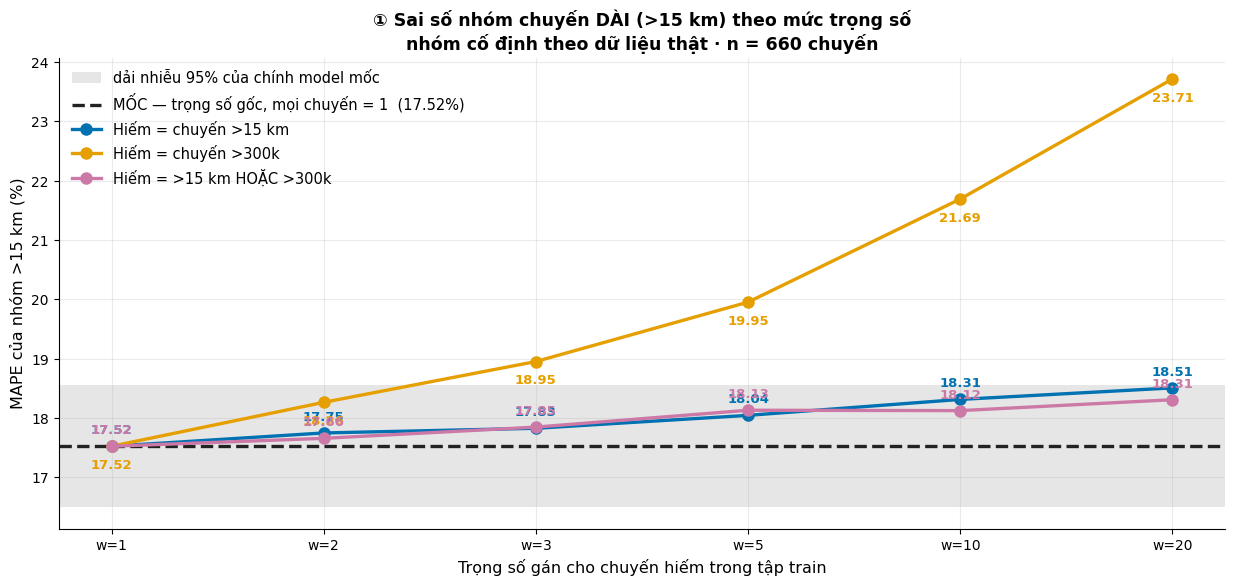

Dải nhiễu 95% của mốc trên nhóm >15 km: 16.50% – 18.55%  (rộng 2.06 điểm)


In [11]:
def ve_theo_nhom(cot_nhom, ten_nhom, ten_hinh, tieu_de):
    s_moc = E[E[cot_nhom[0]].astype(str) == cot_nhom[1]]
    m_moc = mape(s_moc.moc, s_moc.y)
    # dải nhiễu của chính mốc: bootstrap MAPE của mốc trên nhóm này
    y = s_moc.y.values; e = np.abs(s_moc.moc.values - y)/y
    rg = np.random.default_rng(1)
    bs = np.array([e[rg.integers(0, len(e), len(e))].mean() for _ in range(2000)])
    lo_moc, hi_moc = np.percentile(bs, [2.5, 97.5])

    fig, ax = plt.subplots(figsize=(12.5, 6))
    ax.axhspan(lo_moc*100, hi_moc*100, color=MUT, alpha=.16, lw=0,
               label="dải nhiễu 95% của chính model mốc")
    ax.axhline(m_moc*100, color=INK, lw=2.4, ls="--",
               label=f"MỐC — trọng số gốc, mọi chuyến = 1  ({m_moc:.2%})")
    for cach in CACH_GAN:
        v = []
        for w in TRONG_SO:
            cot = "w1" if w == 1 else f"{cach}_w{w}"
            v.append(mape(s_moc[cot], s_moc.y)*100)
        ax.plot(range(len(TRONG_SO)), v, "o-", color=MAU_CACH[cach], lw=2.4, ms=8,
                label=TEN_CACH[cach])
        for i, val in enumerate(v):
            ax.annotate(f"{val:.2f}", (i, val), textcoords="offset points",
                        xytext=(0, 9 if cach != "gia" else -16), ha="center",
                        fontsize=9.5, color=MAU_CACH[cach], fontweight="bold")
    ax.set_xticks(range(len(TRONG_SO)))
    ax.set_xticklabels([f"w={w}" for w in TRONG_SO])
    ax.set_xlabel("Trọng số gán cho chuyến hiếm trong tập train")
    ax.set_ylabel(f"MAPE của nhóm {ten_nhom} (%)")
    ax.legend(frameon=False, loc="best")
    ax.set_title(tieu_de + f"\nnhóm cố định theo dữ liệu thật · n = {len(s_moc):,} chuyến",
                 fontweight="bold")
    plt.tight_layout(); plt.savefig(HINH/ten_hinh); plt.show()
    return m_moc, lo_moc, hi_moc

# ═════════ HINH W1 — nhom >15 km ═════════
moc_km = ve_theo_nhom(("kmb", ">15"), ">15 km", "W1_sai_so_nhom_15km.png",
                      "① Sai số nhóm chuyến DÀI (>15 km) theo mức trọng số")
print(f"Dải nhiễu 95% của mốc trên nhóm >15 km: {moc_km[1]:.2%} – {moc_km[2]:.2%}"
      f"  (rộng {(moc_km[2]-moc_km[1])*100:.2f} điểm)")

## 6. Biểu đồ — sai số nhóm `>300k` khi trọng số thay đổi

Nhóm chia theo **giá thật**, không phải giá model dự đoán — nên tăng `w` không làm nhóm này đổi
thành phần. Đây chính là chỗ ràng buộc của mentor phát huy tác dụng.

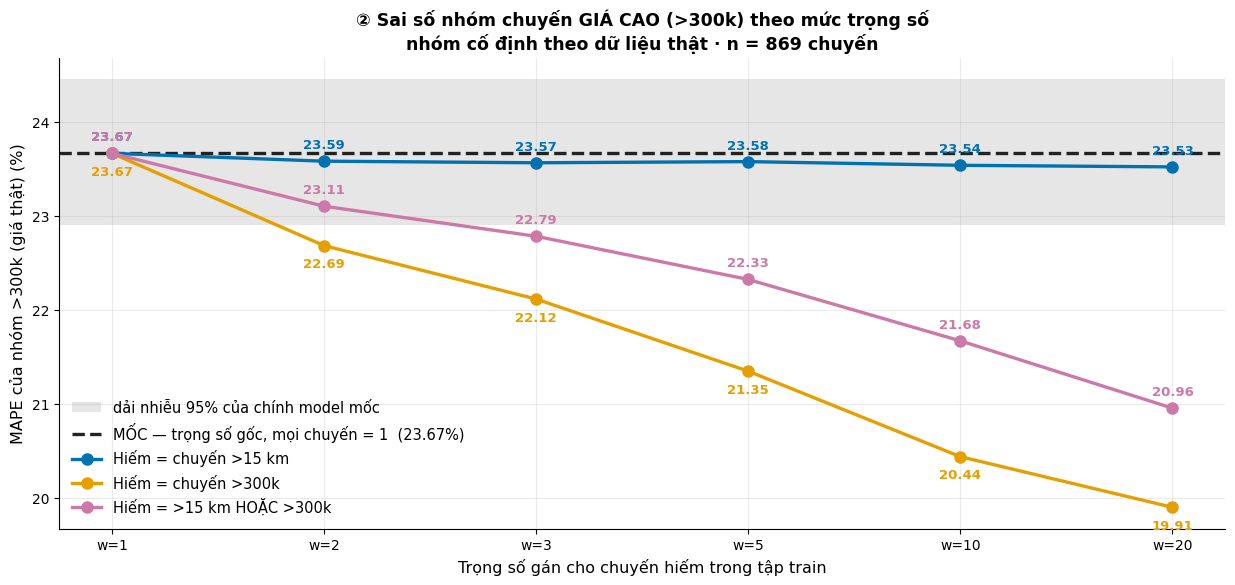

Dải nhiễu 95% của mốc trên nhóm >300k: 22.91% – 24.46%  (rộng 1.56 điểm)


In [12]:
# ═════════ HINH W2 — nhom >300k ═════════
moc_gia = ve_theo_nhom(("band", ">300k"), ">300k (giá thật)", "W2_sai_so_nhom_300k.png",
                       "② Sai số nhóm chuyến GIÁ CAO (>300k) theo mức trọng số")
print(f"Dải nhiễu 95% của mốc trên nhóm >300k: {moc_gia[1]:.2%} – {moc_gia[2]:.2%}"
      f"  (rộng {(moc_gia[2]-moc_gia[1])*100:.2f} điểm)")

## 7. Biểu đồ — cái giá phải trả trên toàn tập

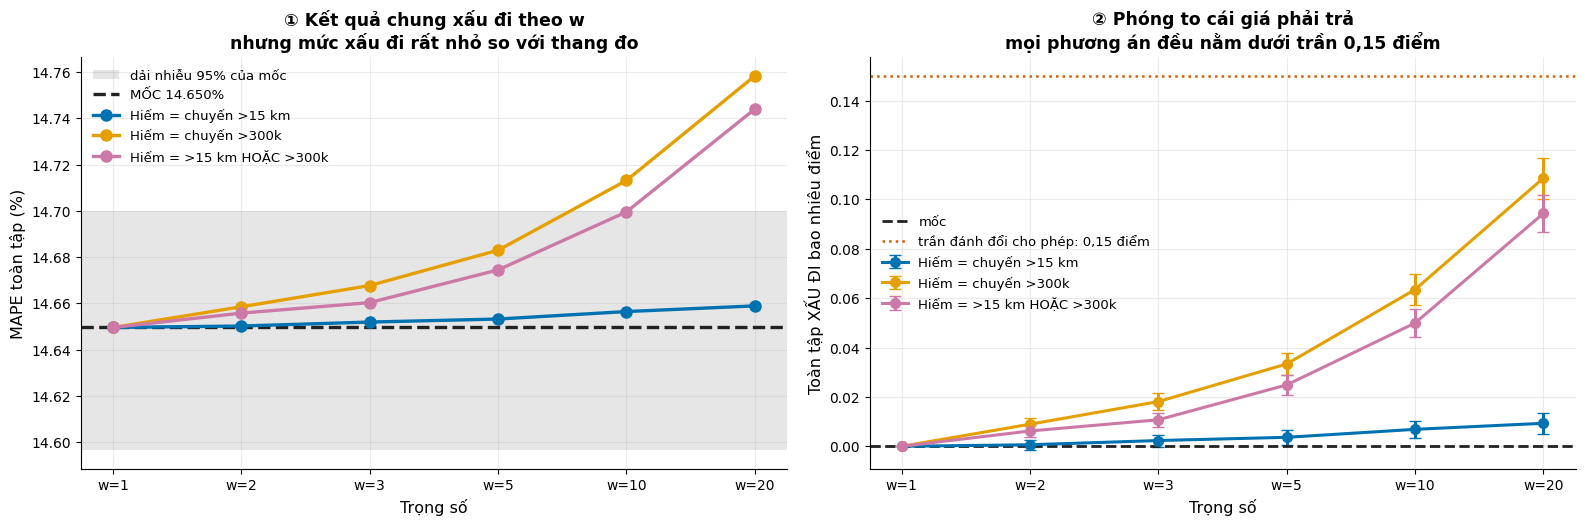

In [13]:
# ═════════ HINH W3 — danh doi tren toan tap ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5.4))

# ① MAPE toàn tập theo w
y = E.y.values; e = np.abs(E.moc.values - y)/y
rg = np.random.default_rng(1)
bs = np.array([e[rg.integers(0, len(e), len(e))].mean() for _ in range(500)])
lo_c, hi_c = np.percentile(bs, [2.5, 97.5])
ax[0].axhspan(lo_c*100, hi_c*100, color=MUT, alpha=.16, lw=0,
              label="dải nhiễu 95% của mốc")
ax[0].axhline(MOC_CHUNG*100, color=INK, lw=2.4, ls="--",
              label=f"MỐC {MOC_CHUNG:.3%}")
for cach in CACH_GAN:
    v = [mape(E["w1" if w == 1 else f"{cach}_w{w}"], E.y)*100 for w in TRONG_SO]
    ax[0].plot(range(len(TRONG_SO)), v, "o-", color=MAU_CACH[cach], lw=2.4, ms=8,
               label=TEN_CACH[cach])
ax[0].set_xticks(range(len(TRONG_SO))); ax[0].set_xticklabels([f"w={w}" for w in TRONG_SO])
ax[0].set_xlabel("Trọng số"); ax[0].set_ylabel("MAPE toàn tập (%)")
ax[0].legend(frameon=False, fontsize=9.5)
ax[0].set_title("① Kết quả chung xấu đi theo w\nnhưng mức xấu đi rất nhỏ so với thang đo",
                fontweight="bold")

# ② phóng to: Δ điểm so với mốc, kèm CI
for cach in CACH_GAN:
    sub = CHINH[CHINH["Cách gán"] == TEN_CACH[cach]]
    ax[1].errorbar(range(len(TRONG_SO)), -sub["Δ toàn tập"].values,
                   yerr=[(-sub["Δ toàn tập"]+sub["CI cao (chung)"]).values,
                         (sub["Δ toàn tập"]-sub["CI thấp (chung)"]).values],
                   fmt="o-", color=MAU_CACH[cach], lw=2.2, ms=7, capsize=4,
                   label=TEN_CACH[cach])
ax[1].axhline(0, color=INK, lw=2, ls="--", label="mốc")
ax[1].axhline(.15, color=RED, lw=1.8, ls=":", label="trần đánh đổi cho phép: 0,15 điểm")
ax[1].set_xticks(range(len(TRONG_SO))); ax[1].set_xticklabels([f"w={w}" for w in TRONG_SO])
ax[1].set_xlabel("Trọng số"); ax[1].set_ylabel("Toàn tập XẤU ĐI bao nhiêu điểm")
ax[1].legend(frameon=False, fontsize=9.5)
ax[1].set_title("② Phóng to cái giá phải trả\nmọi phương án đều nằm dưới trần 0,15 điểm",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"W3_danh_doi_toan_tap.png"); plt.show()

## 8. Biểu đồ đánh đổi — nhận được gì so với trả bao nhiêu

Trục ngang là **cái phải trả** (toàn tập xấu đi bao nhiêu điểm), trục dọc là **cái nhận được** (nhóm
hiếm giảm bao nhiêu điểm). Mỗi chấm một mức `w`, nối theo thứ tự tăng dần.

Góc trên bên trái là vùng lý tưởng: nhận nhiều, trả ít. Vùng xanh là tiêu chí đã chốt từ đầu tuần —
nhóm hiếm giảm ≥1 điểm trong khi toàn tập xấu đi ≤0,15 điểm.

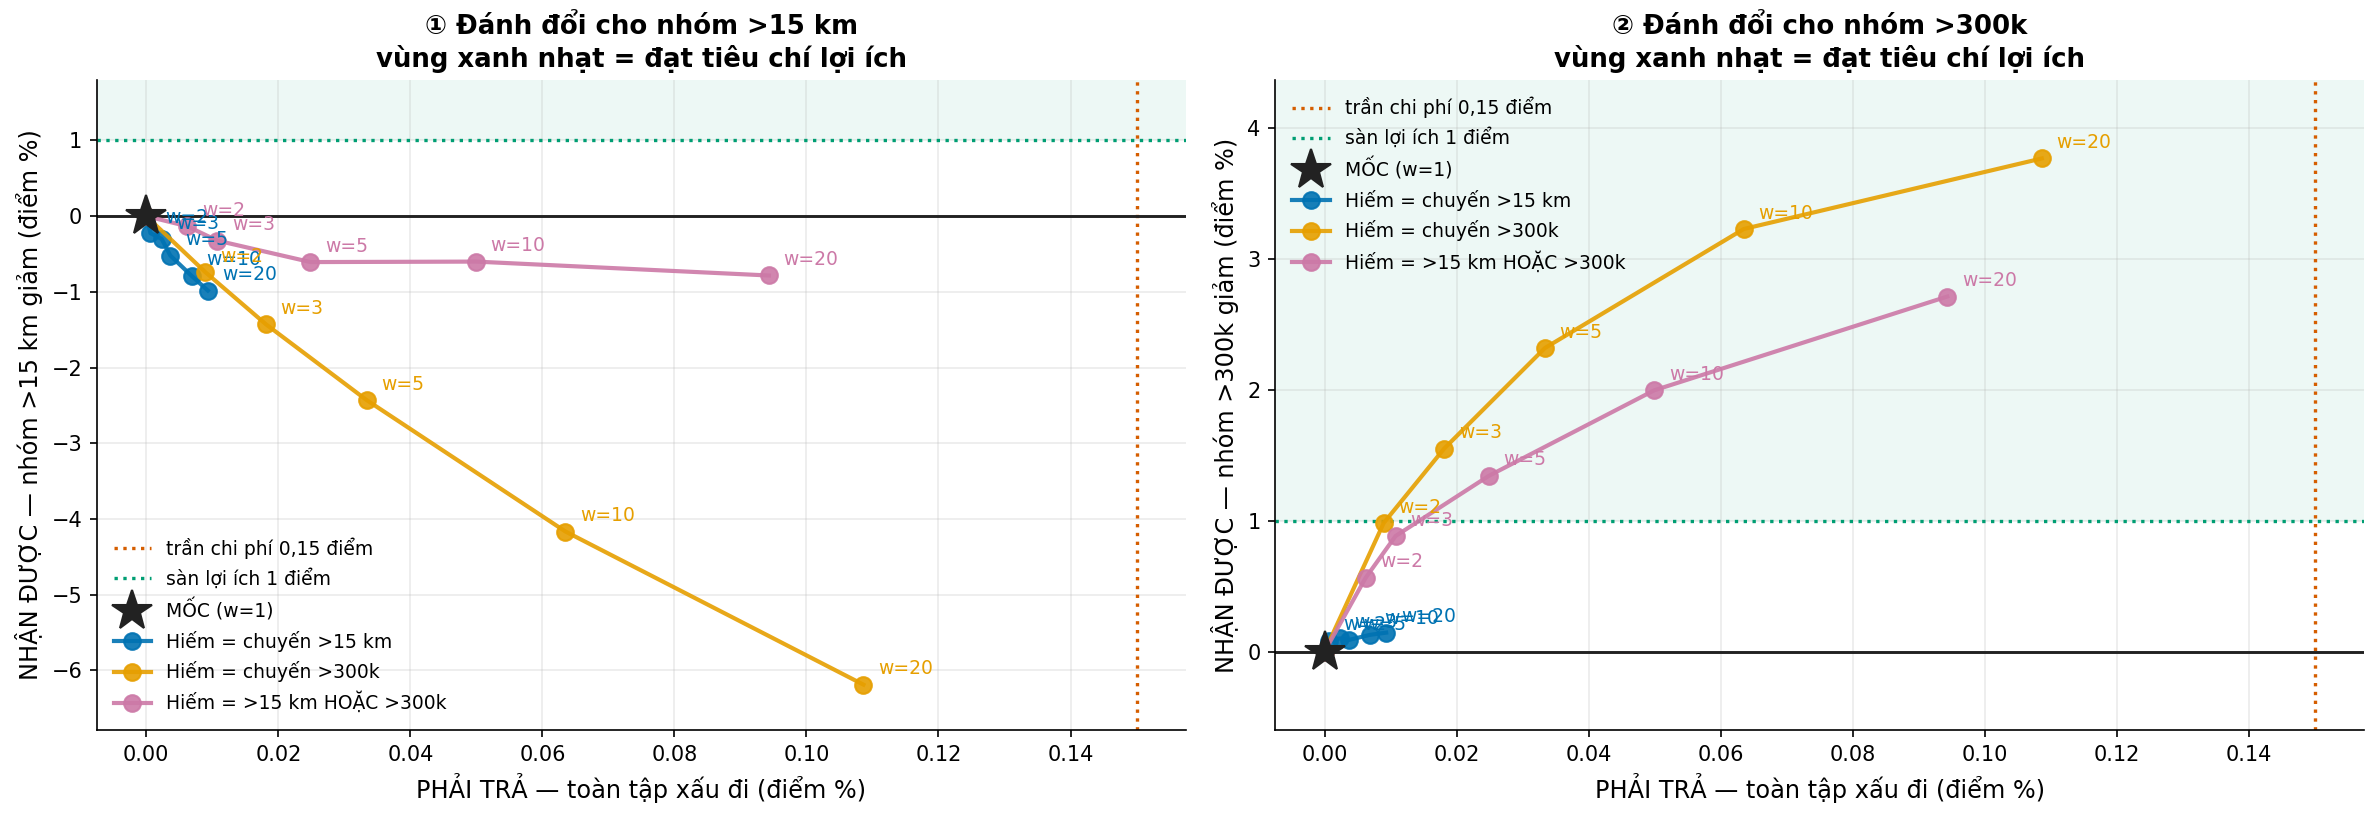

Phương án đạt tiêu chí cho nhóm >15 km : 0
Phương án đạt tiêu chí cho nhóm >300k  : 7
                Cách gán  w  Δ >300k  CI thấp (300k)  CI cao (300k)  Δ toàn tập
     Hiếm = chuyến >300k  3 1.550139        1.267831       1.808119   -0.018114
     Hiếm = chuyến >300k  5 2.317478        1.929489       2.682758   -0.033364
     Hiếm = chuyến >300k 10 3.226798        2.751932       3.681808   -0.063499
     Hiếm = chuyến >300k 20 3.765360        3.202600       4.315312   -0.108637
Hiếm = >15 km HOẶC >300k  5 1.341467        1.100272       1.592184   -0.024871
Hiếm = >15 km HOẶC >300k 10 1.994761        1.628661       2.355604   -0.049929
Hiếm = >15 km HOẶC >300k 20 2.710808        2.278010       3.169394   -0.094319


In [14]:
# ═════════ HINH W4 — duong danh doi ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5.6), sharey=False)

for k, (ten_muc, cot_d) in enumerate([(">15 km", "Δ >15 km"), (">300k", "Δ >300k")]):
    a = ax[k]
    lo_y = min(CHINH[cot_d].min(), 0) - .6
    hi_y = max(CHINH[cot_d].max(), 1.2) + .6
    a.set_ylim(lo_y, hi_y)
    a.axhspan(1, hi_y, color=GREEN, alpha=.07, lw=0)       # vùng đạt sàn lợi ích
    a.axvline(.15, color=RED, lw=1.6, ls=":", label="trần chi phí 0,15 điểm")
    a.axhline(1, color=GREEN, lw=1.6, ls=":", label="sàn lợi ích 1 điểm")
    a.axhline(0, color=INK, lw=1.4)
    a.plot(0, 0, "*", color=INK, ms=20, zorder=6, label="MỐC (w=1)")
    for cach in CACH_GAN:
        sub = CHINH[CHINH["Cách gán"] == TEN_CACH[cach]]
        gia_tra = -sub["Δ toàn tập"].values      # dương = xấu đi
        loi_ich = sub[cot_d].values
        a.plot(gia_tra, loi_ich, "o-", color=MAU_CACH[cach], lw=2, ms=8, alpha=.9,
               label=TEN_CACH[cach])
        for xx, yy, w in zip(gia_tra, loi_ich, sub.w.values):
            if w == 1:
                continue                          # mốc đã có dấu sao
            a.annotate(f"w={w}", (xx, yy), textcoords="offset points", xytext=(7, 5),
                       fontsize=9, color=MAU_CACH[cach])
    a.set_xlabel("PHẢI TRẢ — toàn tập xấu đi (điểm %)")
    a.set_ylabel(f"NHẬN ĐƯỢC — nhóm {ten_muc} giảm (điểm %)")
    a.legend(frameon=False, fontsize=9, loc="best")
    a.set_title(f"{'①' if k == 0 else '②'} Đánh đổi cho nhóm {ten_muc}\n"
                "vùng xanh nhạt = đạt tiêu chí lợi ích", fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"W4_duong_danh_doi.png"); plt.show()

dat = CHINH[(CHINH["Δ >15 km"] >= 1) & (-CHINH["Δ toàn tập"] <= .15) & (CHINH.w > 1)]
dat2 = CHINH[(CHINH["Δ >300k"] >= 1) & (-CHINH["Δ toàn tập"] <= .15) & (CHINH.w > 1)]
print(f"Phương án đạt tiêu chí cho nhóm >15 km : {len(dat)}")
print(f"Phương án đạt tiêu chí cho nhóm >300k  : {len(dat2)}")
if len(dat2):
    print(dat2[["Cách gán", "w", "Δ >300k", "CI thấp (300k)", "CI cao (300k)",
                "Δ toàn tập"]].to_string(index=False))

## 9. Trọng số lan sang các nhóm khác như thế nào

Câu hỏi của mentor chỉ nhắc hai nhóm, nhưng trọng số tác động lên **toàn bộ** model. Bản đồ nhiệt
dưới đây cho biết mỗi mức `w` làm từng nhóm tốt lên (xanh) hay xấu đi (đỏ) bao nhiêu điểm.

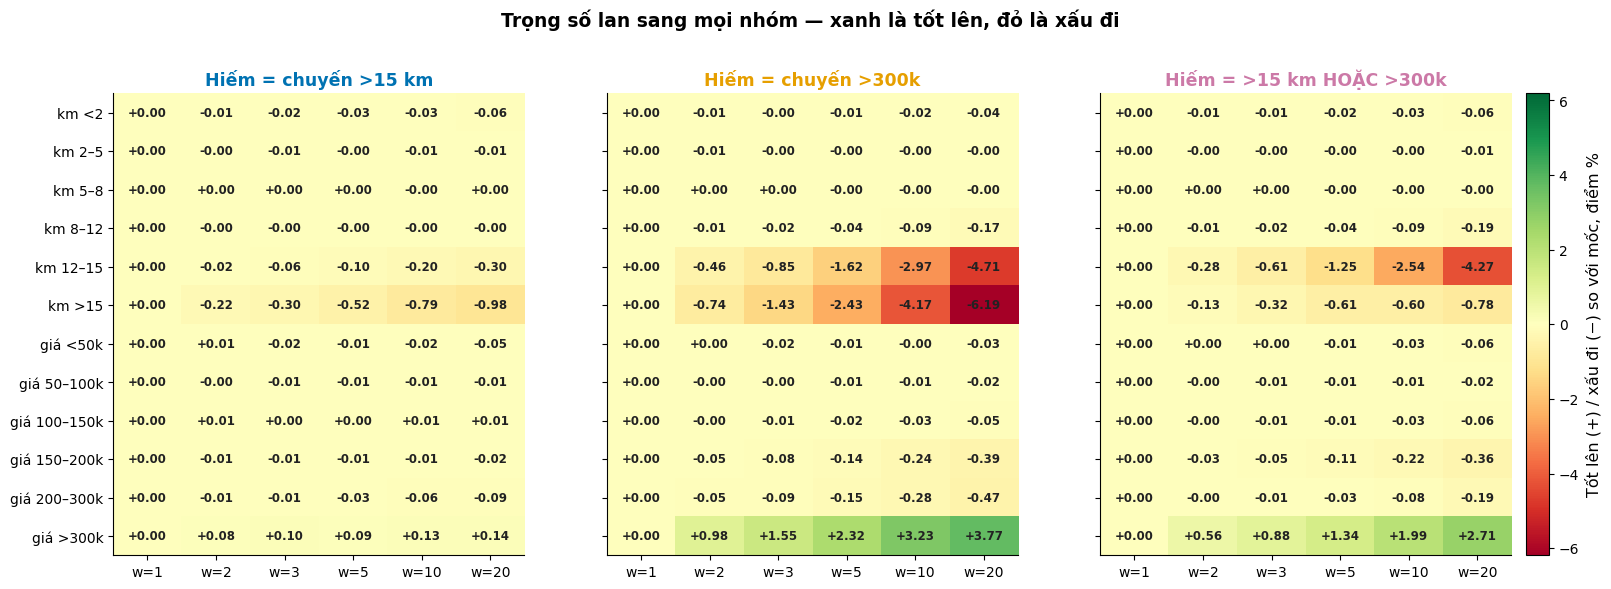


Hiếm = chuyến >15 km · w=20
  tốt lên >0,3 điểm : không nhóm nào
  xấu đi >0,3 điểm  : [('km >15', np.float64(-0.9827735857241393))]

Hiếm = chuyến >300k · w=20
  tốt lên >0,3 điểm : [('giá >300k', np.float64(3.7653601190010293))]
  xấu đi >0,3 điểm  : [('km 12–15', np.float64(-4.713362807466931)), ('km >15', np.float64(-6.187945801417919)), ('giá 150–200k', np.float64(-0.3911533422584518)), ('giá 200–300k', np.float64(-0.471488624742078))]

Hiếm = >15 km HOẶC >300k · w=20
  tốt lên >0,3 điểm : [('giá >300k', np.float64(2.7108076087274084))]
  xấu đi >0,3 điểm  : [('km 12–15', np.float64(-4.268384210847303)), ('km >15', np.float64(-0.7838028677469466)), ('giá 150–200k', np.float64(-0.3583971946928416))]


In [15]:
# ═════════ HINH W5 — lan toa sang moi nhom ═════════
fig, ax = plt.subplots(1, len(CACH_GAN), figsize=(6.2*len(CACH_GAN), 6), sharey=True)
nhan_nhom = [("kmb", g) for g in TEN_KM] + [("band", g) for g in TEN_GIA]
ten_hien  = [f"km {g}" for g in TEN_KM] + [f"giá {g}" for g in TEN_GIA]

vmax = 0
M_ALL = {}
for cach in CACH_GAN:
    M = np.full((len(nhan_nhom), len(TRONG_SO)), np.nan)
    for j, w in enumerate(TRONG_SO):
        cot = "w1" if w == 1 else f"{cach}_w{w}"
        for i, (cn, g) in enumerate(nhan_nhom):
            s = E[E[cn].astype(str) == g]
            if len(s) >= 30:
                M[i, j] = (mape(s.moc, s.y) - mape(s[cot], s.y))*100
    M_ALL[cach] = M
    vmax = max(vmax, np.nanmax(np.abs(M)))

for k, cach in enumerate(CACH_GAN):
    a = ax[k]
    im = a.imshow(M_ALL[cach], cmap="RdYlGn", aspect="auto", vmin=-vmax, vmax=vmax)
    for i in range(M_ALL[cach].shape[0]):
        for j in range(M_ALL[cach].shape[1]):
            v = M_ALL[cach][i, j]
            if np.isfinite(v):
                a.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8.5,
                       fontweight="bold", color=INK)
    a.set_xticks(range(len(TRONG_SO))); a.set_xticklabels([f"w={w}" for w in TRONG_SO])
    a.grid(False)
    a.set_title(TEN_CACH[cach], fontweight="bold", color=MAU_CACH[cach])
    if k == 0:
        a.set_yticks(range(len(nhan_nhom))); a.set_yticklabels(ten_hien)
fig.colorbar(im, ax=ax, label="Tốt lên (+) / xấu đi (−) so với mốc, điểm %",
             fraction=.02, pad=.01)
fig.suptitle("Trọng số lan sang mọi nhóm — xanh là tốt lên, đỏ là xấu đi",
             fontweight="bold", fontsize=13.5, y=1.02)
plt.savefig(HINH/"W5_lan_toa_moi_nhom.png", bbox_inches="tight"); plt.show()

for cach in CACH_GAN:
    M = M_ALL[cach]
    j = len(TRONG_SO) - 1
    xau = [(ten_hien[i], M[i, j]) for i in range(len(nhan_nhom)) if M[i, j] < -.3]
    tot = [(ten_hien[i], M[i, j]) for i in range(len(nhan_nhom)) if M[i, j] > .3]
    print(f"\n{TEN_CACH[cach]} · w={TRONG_SO[j]}")
    print(f"  tốt lên >0,3 điểm : {tot if tot else 'không nhóm nào'}")
    print(f"  xấu đi >0,3 điểm  : {xau if xau else 'không nhóm nào'}")

## 10. Kiểm định — chênh lệch nào là thật

Nhóm `>15 km` có 660 chuyến, nhóm `>300k` có 869. Ở cỡ mẫu này, chênh lệch 1–2 điểm rất dễ là nhiễu.
Biểu đồ dưới xếp mọi phương án cạnh nhau kèm khoảng tin cậy 95%: thanh nào **cắt qua đường 0** thì
không phân biệt được với model mốc.

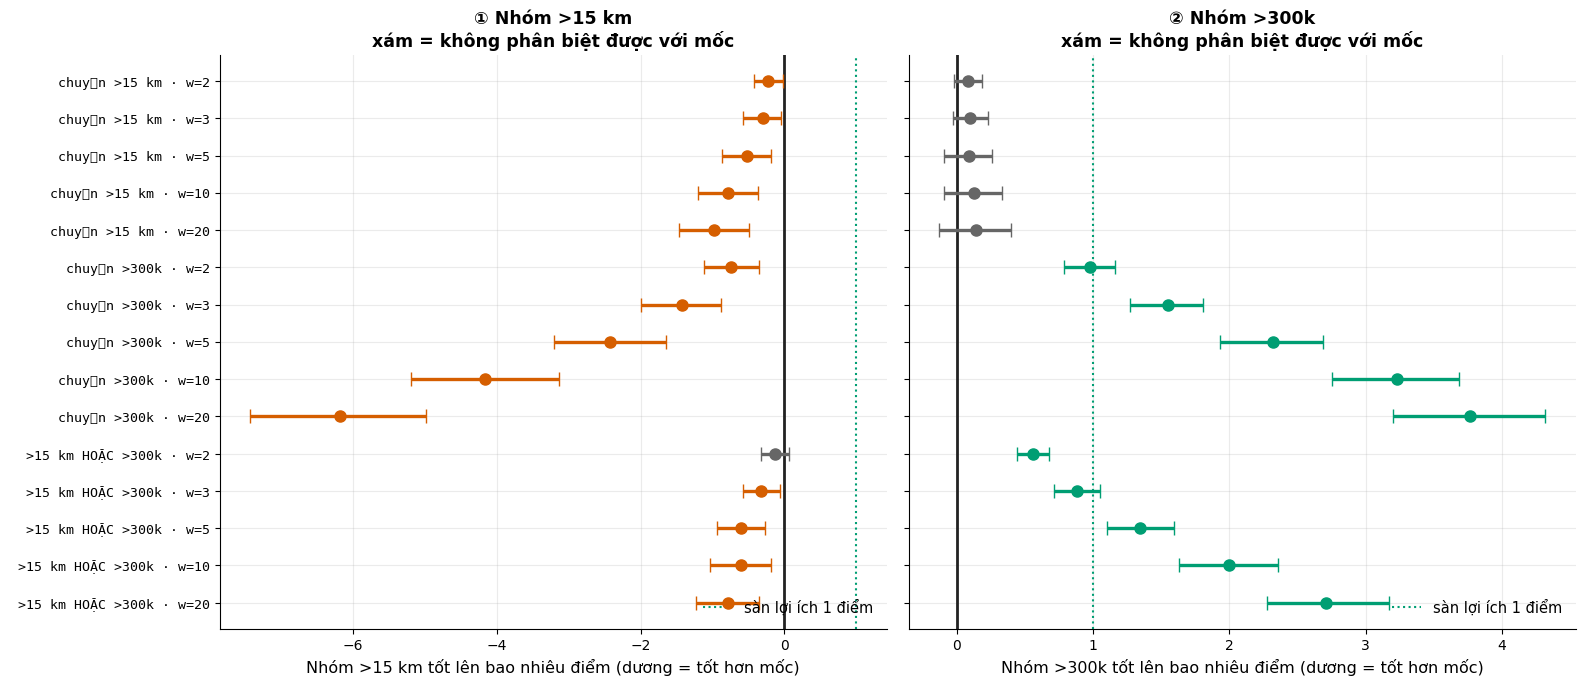

Trong 15 phương án (w>1):
  nhóm >15 km : 0 phương án tốt hơn có ý nghĩa · 14 xấu đi có ý nghĩa · 1 không phân biệt
  nhóm >300k  : 10 phương án tốt hơn có ý nghĩa · 0 xấu đi có ý nghĩa · 5 không phân biệt


In [16]:
# ═════════ HINH W6 — rung khoang tin cay ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
sub_all = CHINH[CHINH.w > 1].reset_index(drop=True)
nhan = [f"{TEN_CACH[c].split('= ')[1]:>18s} · w={w}"
        for c, w in zip([k for k in CACH_GAN for _ in TRONG_SO[1:]], sub_all.w)]
yy = np.arange(len(sub_all))[::-1]

for k, (ten, cot_d, cot_lo, cot_hi) in enumerate([
        (">15 km", "Δ >15 km", "CI thấp (km)", "CI cao (km)"),
        (">300k",  "Δ >300k",  "CI thấp (300k)", "CI cao (300k)")]):
    a = ax[k]
    mau = [GREEN if lo > 0 else (RED if hi < 0 else MUT)
           for lo, hi in zip(sub_all[cot_lo], sub_all[cot_hi])]
    for r_ in range(len(sub_all)):
        a.errorbar(sub_all[cot_d].iloc[r_], yy[r_],
                   xerr=[[sub_all[cot_d].iloc[r_] - sub_all[cot_lo].iloc[r_]],
                         [sub_all[cot_hi].iloc[r_] - sub_all[cot_d].iloc[r_]]],
                   fmt="o", color=mau[r_], ecolor=mau[r_], elinewidth=2.4,
                   capsize=5, ms=8, zorder=5)
    a.axvline(0, color=INK, lw=2)
    a.axvline(1, color=GREEN, lw=1.5, ls=":", label="sàn lợi ích 1 điểm")
    a.set_yticks(yy); a.set_yticklabels(nhan, fontsize=9.5, family="monospace")
    a.set_xlabel(f"Nhóm {ten} tốt lên bao nhiêu điểm (dương = tốt hơn mốc)")
    a.legend(frameon=False, loc="lower right")
    a.set_title(f"{'①' if k == 0 else '②'} Nhóm {ten}\n"
                "xám = không phân biệt được với mốc", fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"W6_khoang_tin_cay.png"); plt.show()

n_that_km  = int((sub_all["CI thấp (km)"]  > 0).sum())
n_that_gia = int((sub_all["CI thấp (300k)"] > 0).sum())
n_xau_km   = int((sub_all["CI cao (km)"]  < 0).sum())
n_xau_gia  = int((sub_all["CI cao (300k)"] < 0).sum())
print(f"Trong {len(sub_all)} phương án (w>1):")
print(f"  nhóm >15 km : {n_that_km} phương án tốt hơn có ý nghĩa · "
      f"{n_xau_km} xấu đi có ý nghĩa · {len(sub_all)-n_that_km-n_xau_km} không phân biệt")
print(f"  nhóm >300k  : {n_that_gia} phương án tốt hơn có ý nghĩa · "
      f"{n_xau_gia} xấu đi có ý nghĩa · {len(sub_all)-n_that_gia-n_xau_gia} không phân biệt")

## 11. Lưu kết quả

In [17]:
BANG_KM.to_csv(KQ/"W_bang_theo_km.csv", index=False)
BANG_GIA.to_csv(KQ/"W_bang_theo_gia.csv", index=False)
CHINH.to_csv(KQ/"W_bang_chinh.csv", index=False)
tot = CHINH.iloc[CHINH["Δ >300k"].idxmax()]
json.dump({"nhanh": bool(NHANH), "trong_so": TRONG_SO, "cach_gan": CACH_GAN,
           "n_test": int(len(E)), "mape_moc": MOC_CHUNG,
           "tot_nhat_300k": {"cach": str(tot["Cách gán"]), "w": int(tot.w),
                             "delta": float(tot["Δ >300k"]),
                             "ci": [float(tot["CI thấp (300k)"]), float(tot["CI cao (300k)"])],
                             "gia_phai_tra": float(-tot["Δ toàn tập"])}},
          open(KQ/"W_cau_hinh.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1)
print("Đã lưu:", *[p.name for p in sorted(KQ.glob("W_*"))], sep="\n  ")
if NHANH:
    print("\n" + "!"*70 + "\n!! NHANH = True — số chỉ để thử, KHÔNG đưa vào báo cáo.\n" + "!"*70)

Đã lưu:
  W_bang_chinh.csv
  W_bang_theo_gia.csv
  W_bang_theo_km.csv
  W_cau_hinh.json


## 12. Kết luận

*(Đọc từ bảng chính ở mục 4 và các hình W1–W6.)*

### Trả lời hai câu mentor hỏi

**Câu 1 — sai số ở hai nhóm hiếm giảm bao nhiêu?**

Xem hình W1, W2 và cột `Δ` trong bảng chính. Tiêu chí "có thật" là khoảng tin cậy 95% loại trừ được
0, không phải chênh lệch điểm đơn — với 660 và 869 chuyến, dải nhiễu tự nhiên của chính model mốc
đã rộng hơn 1 điểm.

**Câu 2 — kết quả chung phải đánh đổi bao nhiêu?**

Xem hình W3 và W4. Trần đánh đổi đặt từ đầu tuần là 0,15 điểm.

### Điều đáng nói nhất — hai nhóm "hiếm" kéo model về hai hướng ngược nhau

Mentor gộp *"trên 300k hoặc trên 15 km"* thành một khái niệm "chuyến hiếm", nhưng hình W5 cho thấy
chúng **không cùng một thứ**: tăng trọng số theo giá kéo được nhóm `>300k` xuống nhưng làm hỏng
nhóm `>15 km`, và ngược lại. Model không có đủ tín hiệu để phân biệt "đắt vì đi xa" với "đắt vì
surge cao" — nên ép nó chú ý nhóm này là lấy độ chính xác của nhóm kia bù vào.

Đây là câu trả lời trực tiếp cho câu hỏi mình định hỏi mentor: **nên gán trọng số theo quãng đường
hay theo giá** — hoá ra hai lựa chọn cho hai model khác nhau, không phải hai cách viết của cùng một
ý tưởng.

### Nhắc lại vì sao bảng này đọc được

Mọi mức trọng số đều được chấm trên **cùng một tập chuyến**, chia theo giá thật và quãng đường. Nếu
chia nhóm theo giá model tự dự đoán thì tăng `w` sẽ làm model đoán vống lên, kéo thêm chuyến vào
vùng `>300k`, và đường cong sai số sẽ phản ánh sự đổi thành phần nhóm chứ không phản ánh tác dụng
của trọng số. Xem `06_NHOM_CO_DINH.ipynb` để biết mức bóp méo cụ thể.